# Andamento della temperatura mensile italiana
### o di altri paesi

Da un progetto di esame del 2022 svolto dallo studente **Vincenzo Capasso**.

## Analisi della serie storica

Vogliamo determinare un modello dell'andamento della temperatura mensile italiana media. I dati riportano la temperatura media mensile dal 1901 al 2020, tratti da https://climateknowledgeportal.worldbank.org/download-data.

Dati tratti dalla sezione: **Timeseries > CRU (Observed)** (CRU = Climatic Research Unit).

Si tratta delle temperature medie nell'arco di un mese.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from iminuit import Minuit
from iminuit.cost import LeastSquares
import math
import matplotlib.gridspec as gridspec
from scipy.stats import chi2
from scipy.stats import norm
import unicodeitplus

Il nuovo formato per i dati aggiornati fino al 2023 richiede un po' di manipolazione

In [2]:
df_tab=pd.read_excel('data/cru-x0.5_timeseries_tas_timeseries_monthly_1901-2023_mean_historical_cru_ts4.08_mean.xlsx')
df_tab

,code,name,1901-01,1901-02,1901-03,1901-04,1901-05,1901-06,1901-07,1901-08,...,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12
0,ITA,Italy,2.04,0.53,6.21,10.66,14.05,18.81,21.16,20.37,...,9.35,10.63,15.65,20.96,23.98,23.23,21.34,17,10.26,7.4


Torniamo al formato precedente, più semplice da manipolare

In [3]:
df_tab=pd.read_csv('data/tas_timeseries_monthly_cru_1901-2021_ITA.csv', skiprows=[0,1])
df_tab.rename(columns={'Unnamed: 0' :'year'}, inplace=True)
df_tab

,year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,1901,1.90,0.75,6.50,10.67,13.91,19.03,21.11,20.58,17.89,13.16,6.94,5.51
1,1902,4.51,5.55,7.07,11.78,11.34,17.04,21.36,20.83,17.96,12.78,7.07,3.93
2,1903,3.33,5.35,7.90,7.89,14.32,16.88,20.17,20.87,17.90,13.64,8.23,5.28
3,1904,3.72,5.73,7.35,11.37,15.39,19.39,22.67,21.31,16.16,12.80,6.71,4.79
4,1905,0.95,3.05,7.43,10.17,13.57,18.25,22.61,21.23,18.74,10.04,8.74,5.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,2017,2.52,7.20,9.99,11.48,16.38,21.65,23.17,23.86,17.41,14.24,8.66,4.78
117,2018,6.91,4.27,7.60,13.67,16.91,20.34,23.31,23.56,20.07,15.46,10.57,6.19
118,2019,3.93,6.66,9.21,11.51,13.24,21.50,23.60,23.52,19.55,15.68,10.33,7.65
119,2020,6.04,7.89,8.32,12.45,16.26,19.05,22.57,23.42,19.68,13.40,10.55,6.41


Cambiamo il formato della tabella usando la funzione [```melt```](https://pandas.pydata.org/docs/reference/api/pandas.melt.html).

Definiamo un valore numerico ```data``` conveniente per mostrare i mesi in scala opportuna.

In [4]:
df = pd.melt(df_tab, id_vars=["year"], var_name="month", value_name = "temp")
df

,year,month,temp
0,1901,Jan,1.90
1,1902,Jan,4.51
2,1903,Jan,3.33
3,1904,Jan,3.72
4,1905,Jan,0.95
...,...,...,...
1447,2017,Dec,4.78
1448,2018,Dec,6.19
1449,2019,Dec,7.65
1450,2020,Dec,6.41


In [5]:
df['temp_err'] = 1.267
df['m'] = pd.to_datetime(df.month, format='%b').dt.month
df['date'] = df['year']+(df['m'] - 1)/12
df = df.sort_values(by=['date'])
df

,year,month,temp,temp_err,m,date
0,1901,Jan,1.90,1.267,1,1901.000000
121,1901,Feb,0.75,1.267,2,1901.083333
242,1901,Mar,6.50,1.267,3,1901.166667
363,1901,Apr,10.67,1.267,4,1901.250000
484,1901,May,13.91,1.267,5,1901.333333
...,...,...,...,...,...,...
967,2021,Aug,22.69,1.267,8,2021.583333
1088,2021,Sep,20.09,1.267,9,2021.666667
1209,2021,Oct,13.76,1.267,10,2021.750000
1330,2021,Nov,9.81,1.267,11,2021.833333


In [6]:
y_min, y_max = df.date.min(), df.date.max()
y_delta = y_max - y_min

Grafico dell'andamento temporale.

È evidente la struttura periodica con modulazione annuale.

Negli ultimi anni va cercato un accenno all'aumento della temperatura.

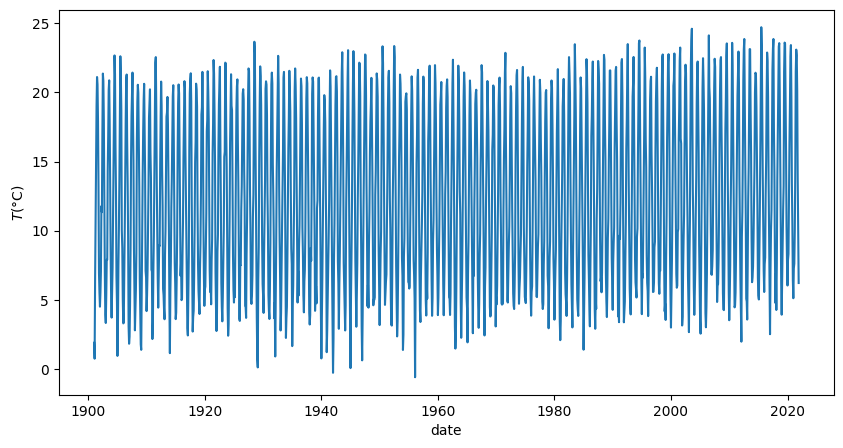

In [7]:
plt.figure(figsize=(10,5))
plt.plot(df.date, df.temp)
plt.ylabel('$T$(°C)' )
plt.xlabel('date')
plt.show()

Definiamo una funzione per il calcolo del $\chi^2$ del fit e del corrispondente $p$-value.

In [8]:
def chi2_p(df, m):
    chi_sq, ndof = m.fval, len(df.date) - m.nfit
    print("chi^2={:.2f}/{:d}={:.2f}".format(chi_sq, ndof, chi_sq/ndof))
    p_val = chi2.sf(chi_sq, ndof)
    print("p-value = {:.5e}".format(p_val))

Definiamo una funzione per fraficare il fit in maniera generica, che servirà anche per i modelli di fit successivi.

In [9]:
def plot_model(m, model, baseline_model, amplitude_model, y1=y_min, y2=y_max):
    y_fit = model(df.date, *m.values)
    npt_curve = 3000
    x_curve = np.linspace(y1, y2, npt_curve)
    y_fit_curve = model(x_curve, *m.values)
    y_base = baseline_model(x_curve, *m.values)
    y_t0 = np.full_like(x_curve, m.values[0])
    y_amp = amplitude_model(x_curve, *m.values)
    y_up, y_lo = y_base + y_amp, y_base - y_amp

    plt.figure(figsize=(12, 8))
    gs = gridspec.GridSpec(8, 1)
    ax0 = plt.subplot(gs[:5, :])
    ax1 = plt.subplot(gs[6:, :])

    ax0.errorbar(df.date, df.temp, df.temp_err, fmt="o", markersize=2, color="blue")
    ax0.plot(x_curve, y_fit_curve, label="modello", color="orange")
    ax0.plot(x_curve, y_base, label="media", color="red")
    ax0.plot(x_curve, y_up, label="massima", color="goldenrod")
    ax0.plot(x_curve, y_lo, label="minima", color="goldenrod")
    ax0.plot(x_curve, y_t0, label=r"$T_0$", color="green")
    ax0.set_ylabel(r"$T_{month}$")

    ax1.plot([y1, y2], [0, 0], color="red", zorder=10)
    ax1.errorbar(df.date, df.temp - y_fit, df.temp_err, fmt="o", markersize=2, color="blue")

    ax0.set_xlabel("time")
    ax1.set_xlabel("time")
    ax1.set_ylabel("res.")
    ax0.set_xlim([y1, y2])
    ax1.set_xlim([y1, y2])
    ndof = len(df.date) - m.npar
    fit_info = [r"$\chi^2$ / $n_\mathrm{{dof}}$ = {:.1f} / {:d}".format(m.fval, ndof)]
    for i in range(m.npar):
        p = m.parameters[i]
        v = m.values[i]
        e = m.errors[i]
        fit_info.append(f"{p} = ${v:.7f} \\pm {e:.7f}$")

    title = "{:.0f}-{:.0f}".format(y1, y2)
    ax0.set_title(title)
    ax0.legend(title="\n".join(fit_info), loc="lower left", ncol=2)
    plt.show()

Definiamo vari modelli possibili di fit che useremo in seguito.

In [10]:
def baseline_const(x, T0):
    return np.full_like(x, T0, dtype=float)

def amplitude_const(x, A0):
    return np.full_like(x, A0, dtype=float)

def model_const_const(x, T0, A0, T, t0):
    return baseline_const(x, T0) + amplitude_const(x, A0) * np.cos((2 * np.pi / T) * (x - t0))

Funzione di fit di base: andamento sinusoidale senza variazione nel tempo della *baseline*:
    
$\displaystyle T(t) = T_0 + A_0 \cos\left(\frac{2\pi}{T}(t-t_0)\right)$

In [11]:
least_squares_model = LeastSquares(df.date, df.temp, df.temp_err, model_const_const)
m = Minuit(least_squares_model, T0=13, A0=10, T=1, t0=0.249)

m.limits["T0"] = (None, None)
m.limits["A0"] = (0, None)
m.limits["T"] = (0.9, 1.1)
m.limits["t0"] = (0, 1)

m.migrad()
m.hesse()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1681 (χ²/ndof = 1.2)       │              Nfcn = 213              │
│ EDM = 1.73e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ T0   │  12.399   │   0.033   │            │            │         │         │       │
│ 1 │ A0   │   8.80    │   0.05    │            │            │    0    │         │       │
│ 2 │ T    │ 1.000005  │ 0.000023  │            │            │   0.9   │   1.1   │       │
│ 3 │ t0   │   0.52    │   0.05    │            │            │    0    │    1    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬─────────────────────────────────────────────┐
│    │         T0         A0          T         t0 │
├────┼─────────────────────────────────────────────┤
│ T0 │    0.00111    -0.0000    -4.5e-9     0.0000 │
│ A0 │    -0.0000    0.00221     1.7e-9    -0.0000 │
│  T │    -4.5e-9     1.7e-9   5.52e-10 -1.0823e-6 │
│ t0 │     0.0000    -0.0000 -1.0823e-6    0.00212 │
└────┴─────────────────────────────────────────────┘

Da notare che il periodo $T$ è compatibile con grade precisione con un anno.

In [12]:
print('hottest date, in months: {:.2f}'.format(1 + m.values[-1]*12))
chi2_p(df, m)

hottest date, in months: 7.20
chi^2=1680.77/1448=1.16
p-value = 1.84948e-05


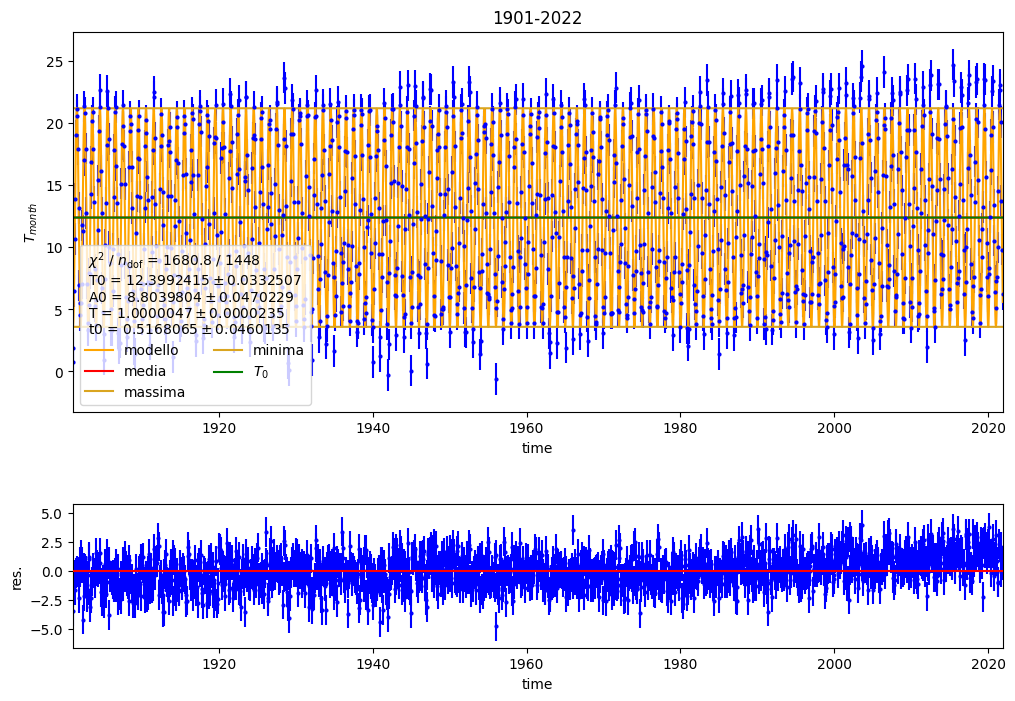

In [13]:
plot_model(
    m,
    model_const_const,
    lambda x, T0, A0, T, t0: baseline_const(x, T0),
    lambda x, T0, A0, T, t0: amplitude_const(x, A0)
)

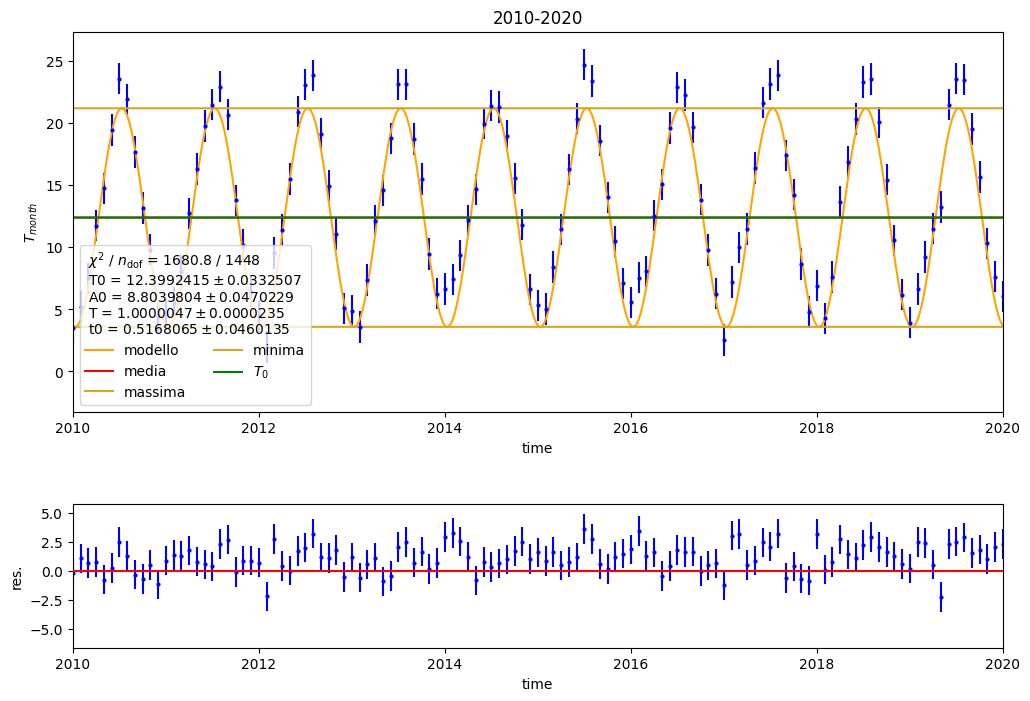

In [14]:
plot_model(
    m,
    model_const_const,
    lambda x, T0, A0, T, t0: baseline_const(x, T0),
    lambda x, T0, A0, T, t0: amplitude_const(x, A0),
    2010, 2020)

I residui mostrano molto chiaramente una discrepanza negli ultimi trent'anni circa.

Prima variazione: modulazione della *baseline* come legge di potenza:
    
$\displaystyle T(t) = T_0 + T_1 \left(\frac{t-t_{\mathrm{min}}}{t_{\mathrm{max}}-t_{\mathrm{min}}}\right)^\alpha+A_0 \cos\left(\frac{2\pi}{T}(t-t_0)\right)$

In [15]:
def baseline_pow(x, T0, T1, alpha):
    z = (x - y_min) / y_delta
    return T0 + T1 * np.power(z, alpha)
    
def model_pow_const(x, T0, T1, alpha, A0, T, t0):
    return baseline_pow(x, T0, T1, alpha) + amplitude_const(x, A0) * np.cos((2 * np.pi / T) * (x - t0))

least_squares_mode = LeastSquares(df.date, df.temp, df.temp_err, model_pow_const)

m_1 = Minuit(
    least_squares_mode,
    T0=m.values["T0"],
    T1=0.0001,
    alpha=1.0001,
    A0=m.values["A0"],
    T=m.values["T"],
    t0=m.values["t0"]
)

m_1.limits["T0"] = (None, None)
m_1.limits["T1"] = (0, None)
m_1.limits["alpha"] = (1, None)
m_1.limits["A0"] = (0, None)
m_1.limits["T"] = (0.9, 1.1)
m_1.limits["t0"] = (0.3, 0.6)

m_1.migrad()
m_1.hesse()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1444 (χ²/ndof = 1.0)       │              Nfcn = 367              │
│ EDM = 1.82e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ T0    │   12.02   │   0.05    │            │            │         │         │       │
│ 1 │ T1    │   1.92    │   0.14    │            │            │    0    │         │       │
│ 2 │ alpha │    4.1    │    0.6    │            │            │    1    │         │       │
│ 3 │ A0    │   8.80    │   0.05    │            │            │    0    │         │       │
│ 4 │ T     │ 1.000002  │ 0.000021  │            │            │   0.9   │   1.1   │       │
│ 5 │ t0    │   0.52    │   0.04    │            │            │   0.3   │   0.6   │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬─────────────────────────────────────────────────────────────┐
│       │        T0        T1     alpha        A0         T        t0 │
├───────┼─────────────────────────────────────────────────────────────┤
│    T0 │   0.00276   -0.0008    0.0200    0.0000   -8.1e-9    0.0000 │
│    T1 │   -0.0008    0.0208     0.045   -0.0000  -33.1e-9    0.0001 │
│ alpha │    0.0200     0.045     0.384   -0.0000 -145.2e-9    0.0003 │
│    A0 │    0.0000   -0.0000   -0.0000   0.00221    1.4e-9   -0.0000 │
│     T │   -8.1e-9  -33.1e-9 -145.2e-9    1.4e-9  4.63e-10 -908.7e-9 │
│    t0 │    0.0000    0.0001    0.0003   -0.0000 -908.7e-9   0.00178 │
└───────┴─────────────────────────────────────────────────────────────┘

In [16]:
chi2_p(df, m_1)

chi^2=1443.96/1446=1.00
p-value = 5.10199e-01


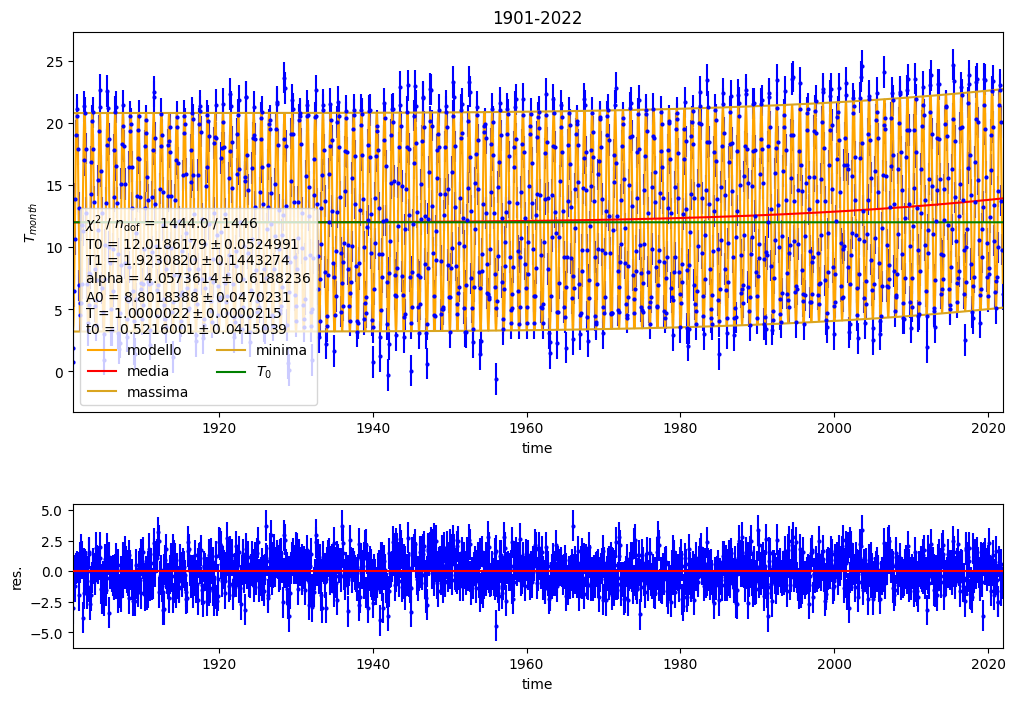

In [17]:
plot_model(
    m_1,
    model_pow_const,
    lambda x, T0, T1, alpha, A0, T, t0: baseline_pow(x, T0, T1, alpha),
    lambda x, T0, T1, alpha, A0, T, t0: amplitude_const(x, A0)
)

Seconda variazione: modulazione dell'ampiezza come legge di potenza:
    
$\displaystyle T(t) = \left[T_0 + T_1 \left(\frac{t-t_{\mathrm{min}}}{t_{\mathrm{max}}-t_{\mathrm{min}}}\right)^\alpha\right]+\left[A_0+A_1 \left(\frac{t-t_{\mathrm{min}}}{t_{\mathrm{max}}-t_{\mathrm{min}}}\right)^\beta \right]\cos\left(\frac{2\pi}{T}(t-t_0)\right)$

In [18]:
def amplitude_pow(x, A0, A1, beta):
    z = (x - y_min) / y_delta
    return A0 + A1 * np.power(z, beta)

def model_pow_pow(x, T0, T1, alpha, A0, A1, beta, T, t0):
    return baseline_pow(x, T0, T1, alpha) + amplitude_pow(x, A0, A1, beta) * np.cos((2 * np.pi / T) * (x - t0))

least_squares_mode = LeastSquares(df.date, df.temp, df.temp_err, model_pow_pow)

m_2 = Minuit(
    least_squares_mode,
    T0=m_1.values["T0"],
    T1=m_1.values["T1"],
    alpha=m_1.values["alpha"],
    A0=m_1.values["A0"],
    A1=0.0001,
    beta=1.0001,
    T=m_1.values["T"],
    t0=m_1.values["t0"]
)

m_2.limits["T0"] = (None, None)
m_2.limits["T1"] = (0, None)
m_2.limits["alpha"] = (1, None)
m_2.limits["A0"] = (0, None)
m_2.limits["A1"] = (0, None)
m_2.limits["beta"] = (1, None)
m_2.limits["T"] = (0.9, 1.1)
m_2.limits["t0"] = (0.3, 0.6)

m_2.migrad()
m_2.hesse()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1441 (χ²/ndof = 1.0)       │              Nfcn = 381              │
│ EDM = 3.73e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ T0    │   12.02   │   0.05    │            │            │         │         │       │
│ 1 │ T1    │   1.92    │   0.14    │            │            │    0    │         │       │
│ 2 │ alpha │    4.1    │    0.6    │            │            │    1    │         │       │
│ 3 │ A0    │   8.75    │   0.06    │            │            │    0    │         │       │
│ 4 │ A1    │   0.35    │   0.21    │            │            │    0    │         │       │
│ 5 │ beta  │     6     │     4     │            │            │    1    │         │       │
│ 6 │ T     │ 1.000002  │ 0.000026  │            │            │   0.9   │   1.1   │       │
│ 7 │ t0    │   0.52    │   0.05    │            │            │   0.3   │   0.6   │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬─────────────────────────────────────────────────────────────────────────────────────────┐
│       │         T0         T1      alpha         A0         A1       beta          T         t0 │
├───────┼─────────────────────────────────────────────────────────────────────────────────────────┤
│    T0 │    0.00276    -0.0008     0.0200     0.0000    -0.0000    -0.0002   -12.1e-9     0.0000 │
│    T1 │    -0.0008     0.0208      0.045     0.0000     -0.000     -0.004   -50.0e-9     0.0001 │
│ alpha │     0.0200      0.045      0.383     0.0001      -0.00       -0.0  -218.5e-9     0.0004 │
│    A0 │     0.0000     0.0000     0.0001    0.00334    -0.0043     0.0729     5.6e-9    -0.0000 │
│    A1 │    -0.0000     -0.000      -0.00    -0.0043     0.0447       0.30    -3.0e-9     0.0000 │
│  beta │    -0.0002     -0.004       -0.0     0.0729       0.30       16.3   417.9e-9    -0.0008 │
│     T │   -12.1e-9   -50.0e-9  -218.5e-9     5.6e-9    -3.0e-9   417.9e-9   6.85e-10 -1.3427e-6 │
│    t0 │     0.0000     0.0001     0.0004    -0.0000     0.0000    -0.0008 -1.3427e-6    0.00263 │
└───────┴─────────────────────────────────────────────────────────────────────────────────────────┘

In [19]:
chi2_p(df, m_2)

chi^2=1440.88/1444=1.00
p-value = 5.18228e-01


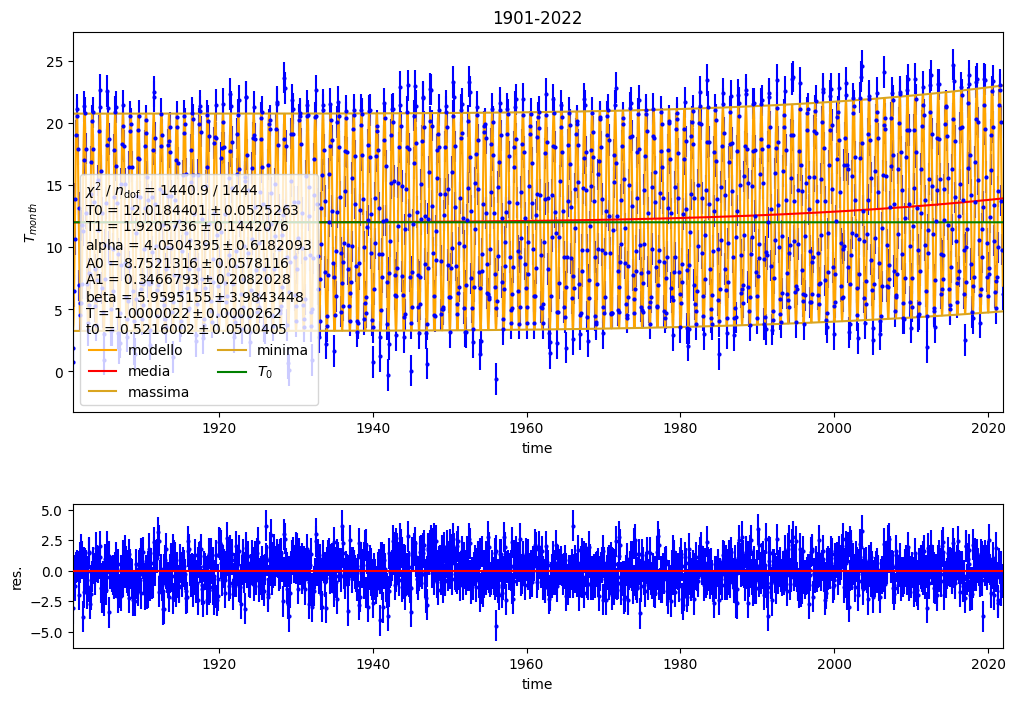

In [20]:
plot_model(
    m_2,
    model_pow_pow,
    lambda x, T0, T1, alpha, A0, A1, beta, T, t0: baseline_pow(x, T0, T1, alpha),
    lambda x, T0, T1, alpha, A0, A1, beta, T, t0: amplitude_pow(x, A0, A1, beta)
)

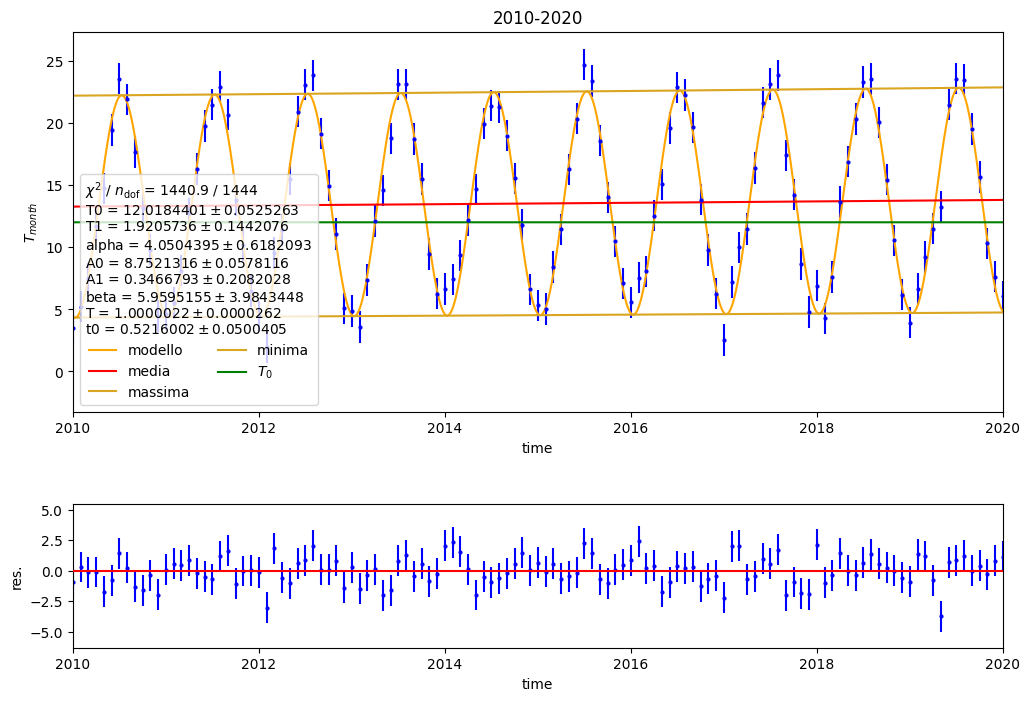

In [21]:
plot_model(
    m_2,
    model_pow_pow,
    lambda x, T0, T1, alpha, A0, A1, beta, T, t0: baseline_pow(x, T0, T1, alpha),
    lambda x, T0, T1, alpha, A0, A1, beta, T, t0: amplitude_pow(x, A0, A1, beta),
    2010,
    2020
)

In [22]:
z = m_2.values[4]/m_2.errors[4]
print('Significance level A1>0: {:.3f}'.format(z))
print('p-value A1>0: {:.5f}'.format(norm.sf(abs(z))))

Significance level A1>0: 1.665
p-value A1>0: 0.04795


Estrapoliamo al 2080. Andrebbe valutato anche l'errore sull'estrapolazione che però richiede una propagazione delle incertezze sui parametri non banale, che per questo esercizio ci risparmiano.

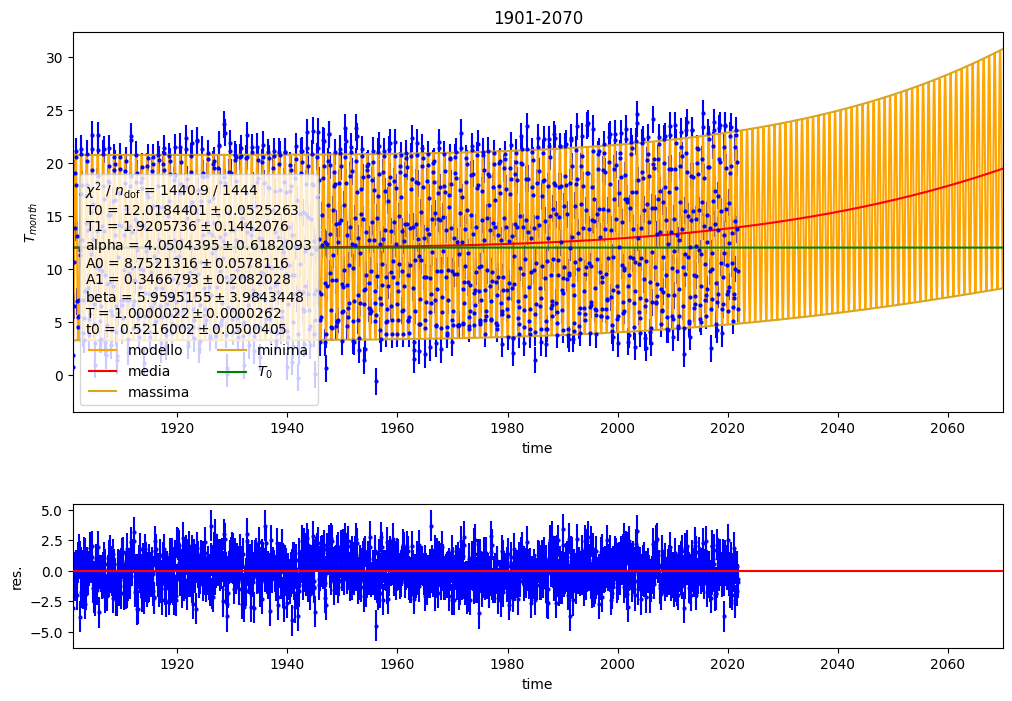

In [23]:
plot_model(
    m_2,
    model_pow_pow,
    lambda x, T0, T1, alpha, A0, A1, beta, T, t0: baseline_pow(x, T0, T1, alpha),
    lambda x, T0, T1, alpha, A0, A1, beta, T, t0: amplitude_pow(x, A0, A1, beta),
    1901,
    2070
)

Chiaramente, l'estrapolazione è arbitraria: la previsione è attendibile solo se il modello assunto di crescita con legge di potenza, è corretto. Un modello corretto può venire solo da studi di climatorlogia che vanno oltre la semplice analisi statistica con modelli empirici.

Se si prova ad usare i dati di alte nazioni si noterà che non in tutti i casi questo modello semplificato funziona bene (es.: Brasile).